# Pipeline de datos de películas: integración de IMDb y TMDb con MongoDB


## Descripción del proyecto

Este proyecto implementa un pequeño pipeline de ingeniería de datos que integra datasets públicos de IMDb con información adicional obtenida desde la API de TMDb.

El objetivo es enriquecer los metadatos de películas combinando múltiples fuentes de datos, procesarlos con Python y almacenarlos en MongoDB para permitir consultas flexibles y análisis posteriores.

## Tecnologías utilizadas

- Python
- Pandas
- Requests (consumo de APIs REST)
- MongoDB
- Jupyter Notebook
- IMDb datasets
- TMDb API

## Arquitectura del pipeline de datos

El flujo de procesamiento del proyecto es el siguiente:

1. Carga de datasets públicos de IMDb.
2. Filtrado de títulos para quedarse únicamente con películas relevantes.
3. Integración con datos de ratings.
4. Enriquecimiento de información utilizando la API de TMDb.
5. Integración de los datos en un único dataset.
6. Almacenamiento en MongoDB.
7. Ejecución de consultas sobre la base de datos resultante.

## 1. Carga de datos de IMDb

La primera fuente de información utilizada en este proyecto es el conjunto de datos público de **IMDb**, que contiene información estructurada sobre películas.

**IMDb** pone a disposición pública algunos conjuntos de datos actualizados en formato `csv` [(enlace)](https://datasets.imdbws.com). En este proyecto se utilizarán los ficheros `title.basics.tsv.gz`, que contiene información básica y metadatos de películas, series y episodios, incluyendo identificadores únicos, títulos, tipos de contenido, años de lanzamiento/finalización, duración y géneros y `title.ratings.gz`, que contiene información sobre las valoraciones hechas a cada película.


### Importación de librerías

Se importan las librerías necesarias para el procesamiento de datos, consumo de APIs y almacenamiento en MongoDB.

In [1]:
# ==============================
# Librerías estándar
# ==============================

import os
import json
import time

# ==============================
# Librerías de terceros
# ==============================

import pandas as pd
import requests
import pymongo

# ==============================
# Utilidades de Jupyter
# ==============================

from IPython.display import Image

In [2]:
# Crear directorio de datos
os.makedirs("data", exist_ok=True)

def download_imdb_dataset(filename, data_dir="data"):
    """
    Download an IMDb dataset if it does not exist locally.
    """
    
    url = f"https://datasets.imdbws.com/{filename}"
    file_path = os.path.join(data_dir, filename)

    if not os.path.exists(file_path):
        print(f"Downloading {filename}...")

        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(file_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

        print(f"{filename} downloaded successfully.")

    else:
        print(f"{filename} already exists.")

# List of datasets to download
datasets = [
    "title.basics.tsv.gz",
    "title.ratings.tsv.gz"
]

# Descarga de datasets
for dataset in datasets:
    download_imdb_dataset(dataset)

title.basics.tsv.gz downloaded successfully.
title.ratings.tsv.gz downloaded successfully.


In [3]:
df_basics = pd.read_csv("data/title.basics.tsv.gz", sep="\t", compression="gzip", index_col=0)

In [4]:
print("Número total de títulos:", len(df_basics))

Número total de títulos: 12356240


In [5]:
df_basics.info()

<class 'pandas.DataFrame'>
Index: 12356240 entries, tt0000001 to tt9916880
Data columns (total 8 columns):
 #   Column          Dtype
---  ------          -----
 0   titleType       str  
 1   primaryTitle    str  
 2   originalTitle   str  
 3   isAdult         int64
 4   startYear       str  
 5   endYear         str  
 6   runtimeMinutes  str  
 7   genres          str  
dtypes: int64(1), str(7)
memory usage: 848.4+ MB


El número total de títulos disponibles en IMDb es muy elevado e incluye:

- películas
- series
- cortometrajes
- episodios
- producciones con muy pocas valoraciones

Este proyecto se centrará solamente en películas, por lo que al dataframe anterior se le aplicará un filtro para eliminar aquellos registros que no sean películas.

In [6]:
# Filtrar solo películas
df_basics = df_basics[df_basics["titleType"] == "movie"].copy()

# Convertir columnas numéricas
df_basics["year"] = pd.to_numeric(df_basics["startYear"], errors="coerce")
df_basics["runtimeMinutes"] = pd.to_numeric(df_basics["runtimeMinutes"], errors="coerce")

# Seleccionar columnas
df_basics = df_basics[[
    "year",
    "primaryTitle",
    "originalTitle",
    "runtimeMinutes",
    "genres"
]]

# Eliminar valores nulos
df_basics = df_basics.dropna(subset=["year", "runtimeMinutes"])

# Filtrar año >= 1927
df_basics = df_basics[df_basics["year"] >= 1927]

# Convertir a enteros
df_basics["year"] = df_basics["year"].astype(int)
df_basics["runtimeMinutes"] = df_basics["runtimeMinutes"].astype(int)

#Eliminar géneros desconocidos (\N)
df_basics = df_basics[df_basics["genres"] != "\\N"]

#convertir géneros a lista
df_basics["genres"] = df_basics["genres"].str.split(",")

df_basics.head()

,year,primaryTitle,originalTitle,runtimeMinutes,genres
tconst,,,,,
tt0003854,1936,Dodge City Trail,Dodge City Trail,56,"[Drama, Music, Western]"
tt0014985,1927,A Hero for a Night,A Hero for a Night,60,[Comedy]
tt0015152,1929,Mustalaishurmaaja,Mustalaishurmaaja,69,"[Drama, Romance]"
tt0015724,1993,Dama de noche,Dama de noche,102,"[Drama, Mystery, Romance]"
tt0016029,1935,The Little Colonel,The Little Colonel,81,"[Comedy, Family, Musical]"


## 2. Carga del dataset de valoraciones

Además de la información básica de cada película, IMDb proporciona datasets adicionales que incluyen **valoraciones de los usuarios**.

En este proyecto se utiliza el archivo:

`title.ratings.tsv.gz`

Este dataset contiene:

- `averageRating` → valoración media de la película
- `numVotes` → número total de votos

Estos datos permiten identificar películas con suficiente volumen de valoración para ser consideradas representativas.

In [7]:
df_ratings = pd.read_csv("data/title.ratings.tsv.gz", sep="\t", compression="gzip", index_col=0)
df_ratings.head()

,averageRating,numVotes
tconst,,
tt0000001,5.7,2199
tt0000002,5.5,310
tt0000003,6.4,2305
tt0000004,5.1,196
tt0000005,6.2,3035


## 3. Filtrado y combinación de datasets

Para centrarnos en películas relevantes, se aplicará un filtro seleccionando únicamente aquellas que tengan **más de 50.000 votos**.

Posteriormente se combinarán los dos datasets disponibles:

- Información básica de películas
- Valoraciones de usuarios

El resultado será un único dataset consolidado con información relevante para cada título, al que se denominará `df_movies` y que contendrá las películas que aparezcan en ambos, es decir:

- películas posteriores a 1927 (año en el que se inorporó el sonido al cine).
- han recibido más de 50000 votos por parte de los usuarios registrados en `IMDB`.

In [8]:
# Filtrar películas con un número significante de votos
df_ratings_filtered = df_ratings[df_ratings['numVotes'] > 50000]

# Merge datasets
df_movies = df_basics.merge(df_ratings_filtered, left_index=True, right_index=True, how='inner')

# Selección de columnas relevantes
df_movies = df_movies[['year', 'runtimeMinutes', 'originalTitle', 'primaryTitle', 'genres', 'averageRating', 'numVotes']].rename(
    columns={
        'primaryTitle':'title',
        'averageRating':'avg_rating',
        'numVotes':'num_votes'
    }
).rename_axis('movie_id')

df_movies.head()

,year,runtimeMinutes,originalTitle,title,genres,avg_rating,num_votes
movie_id,,,,,,,
tt0017136,1927,153,Metropolis,Metropolis,"[Drama, Sci-Fi]",8.2,200258
tt0018455,1927,94,Sunrise: A Song of Two Humans,Sunrise,"[Drama, Romance]",8.1,56514
tt0019254,1928,114,La passion de Jeanne d'Arc,The Passion of Joan of Arc,"[Biography, Drama, History]",8.1,67786
tt0020629,1930,152,All Quiet on the Western Front,All Quiet on the Western Front,"[Drama, War]",8.1,71740
tt0021749,1931,87,City Lights,City Lights,"[Comedy, Drama, Romance]",8.5,215644


In [9]:
print("Número total de películas:", len(df_movies))

Número total de películas: 4536


In [10]:
df_movies.info()

<class 'pandas.DataFrame'>
Index: 4536 entries, tt0017136 to tt9900782
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            4536 non-null   int64  
 1   runtimeMinutes  4536 non-null   int64  
 2   originalTitle   4536 non-null   str    
 3   title           4536 non-null   str    
 4   genres          4536 non-null   object 
 5   avg_rating      4536 non-null   float64
 6   num_votes       4536 non-null   int64  
dtypes: float64(1), int64(3), object(1), str(2)
memory usage: 283.5+ KB


In [11]:
# Ordenar por rating descendente
df_movies_sorted = df_movies.sort_values(
    by=["avg_rating", "num_votes"], 
    ascending=[False, False]
)

# Mostrar las top 10 películas
df_movies_sorted.head(10)

,year,runtimeMinutes,originalTitle,title,genres,avg_rating,num_votes
movie_id,,,,,,,
tt0111161,1994,142,The Shawshank Redemption,The Shawshank Redemption,[Drama],9.3,3166599
tt0068646,1972,175,The Godfather,The Godfather,"[Crime, Drama]",9.2,2211726
tt0468569,2008,152,The Dark Knight,The Dark Knight,"[Action, Crime, Drama]",9.1,3144152
tt0167260,2003,201,The Lord of the Rings: The Return of the King,The Lord of the Rings: The Return of the King,"[Adventure, Drama, Fantasy]",9.0,2151308
tt0108052,1993,195,Schindler's List,Schindler's List,"[Biography, Drama, History]",9.0,1577021
tt0071562,1974,202,The Godfather Part II,The Godfather Part II,"[Crime, Drama]",9.0,1486144
tt0050083,1957,96,12 Angry Men,12 Angry Men,"[Crime, Drama]",9.0,976867
tt0120737,2001,178,The Lord of the Rings: The Fellowship of the Ring,The Lord of the Rings: The Fellowship of the Ring,"[Adventure, Drama, Fantasy]",8.9,2192492
tt1375666,2010,148,Inception,Inception,"[Action, Adventure, Sci-Fi]",8.8,2795100


## 4. Enriquecimiento de datos con la API de TMDb

El dataset original de IMDb proporciona información estructural sobre las películas, como títulos, año de estreno, duración o géneros. Sin embargo, para realizar análisis más completos resulta útil incorporar variables adicionales relacionadas con aspectos económicos, de distribución y de popularidad.

Con este objetivo se utiliza la API de **The Movie Database (TMDb)**, que permite acceder a información detallada sobre películas mediante consultas HTTP.

La API de TMDb es accesible a través de `https://api.themoviedb.org/3/`. En la documentación oficial es posible consultar todos los *endpoints* disponibles y probar directamente las llamadas a la API:  
https://developers.themoviedb.org/3/getting-started/introduction

Además, desde esta documentación se pueden generar ejemplos de llamadas en distintos lenguajes. En el caso de **Python**, se ofrecen dos alternativas principales: una basada en la librería estándar `http.client` y otra utilizando la librería `requests`, que es la opción empleada en este proyecto por su mayor simplicidad y legibilidad.

TMDb proporciona metadatos adicionales muy útiles para el análisis, entre ellos:

- **Budget**: presupuesto de producción.
- **Revenue**: ingresos en taquilla.
- **Release date**: fecha de estreno.
- **Original language**: idioma original de la película.
- **Popularity**: indicador de popularidad dentro de la plataforma.
- **Keywords**: palabras clave.
- **Poster path**: ruta de la imagen del póster.

### Acceso a la API

La API de TMDb requiere autenticación. Para poder utilizarla es necesario disponer de una cuenta y generar una clave de acceso. El proceso es sencillo y consta de tres pasos:

1. Acceder a la **configuración de la cuenta** en TMDb.
2. Entrar en la sección **API**.
3. **Crear una clave de API** para el proyecto.

Una vez generada, la clave puede consultarse dentro de la configuración de la cuenta. En este proyecto se utiliza el token identificado como **"API Key (v3 auth)"**, que se almacenará en la variable `tmdb_token`.

### Estrategia de enriquecimiento del dataset

El proceso de enriquecimiento del dataset se realiza en dos etapas:

1. **Localizar la película en TMDb utilizando el identificador de IMDb (`imdb_id`).**  
   Para ello se utiliza el endpoint `/find`, que permite buscar recursos en TMDb a partir de identificadores externos.

2. **Recuperar los datos completos de la película utilizando el identificador interno de TMDb (`tmdb_id`).**  
   Una vez identificado el recurso, se consulta el endpoint `/movie/{tmdb_id}`, que devuelve información detallada como presupuesto, ingresos, idioma original o popularidad.

Las respuestas de la API se almacenan en la estructura `movie_data`, un diccionario en el que cada clave corresponde al identificador de IMDb de la película y el valor asociado contiene los datos devueltos por TMDb.

Para mejorar la eficiencia del flujo de trabajo y evitar realizar llamadas repetidas a la API, los resultados obtenidos se guardan también en un archivo JSON de respaldo. De esta forma, en ejecuciones posteriores del notebook los datos pueden cargarse directamente desde el archivo local, lo que reduce significativamente el tiempo de ejecución y garantiza la reproducibilidad del análisis.

In [12]:
tmdb_token = 'TU_TMDB_TOKEN'

### Gestión de backups

Para evitar repetir llamadas a la API y reducir el tiempo de ejecución del pipeline,
los resultados obtenidos de TMDb se almacenan localmente en un archivo JSON.

In [13]:
# Ruta del backup
backup_file = "data/backup/tmdb_movies.json"
backup_dir = os.path.dirname(backup_file)

# Crear carpeta si no existe
os.makedirs(backup_dir, exist_ok=True)

# Cargar backup existente si existe
if os.path.exists(backup_file):
    with open(backup_file, "r", encoding="utf-8") as f:
        movie_data = json.load(f)
else:
    movie_data = {}

print(f"Películas ya almacenadas en backup: {len(movie_data)}")

Películas ya almacenadas en backup: 0


### Creación de sesión HTTP

Se utiliza `requests.Session()` para reutilizar conexiones HTTP y mejorar
la estabilidad de las llamadas a la API.

In [14]:
session = requests.Session()

In [15]:
def get_movie_tmdb(imdb_id, retries=3, backoff=1):
    """
    Obtiene los datos de TMDb para un IMDb ID.
    Incluye reintentos con backoff exponencial.
    """

    find_url = f"https://api.themoviedb.org/3/find/{imdb_id}"
    params = {
        "api_key": tmdb_token,
        "external_source": "imdb_id"
    }

    for intento in range(retries):

        try:
            r = session.get(find_url, params=params, timeout=10)

            if r.status_code != 200:
                print(f"[{imdb_id}] Código inesperado {r.status_code}")
                return None

            data_find = r.json()

            if not data_find.get("movie_results"):
                print(f"No se encontró película para IMDb ID {imdb_id}")
                return None

            tmdb_id = data_find["movie_results"][0]["id"]

            movie_url = f"https://api.themoviedb.org/3/movie/{tmdb_id}"
            params_movie = {
                "api_key": tmdb_token,
                "language": "en-US"
            }

            r_movie = session.get(movie_url, params=params_movie)

            if r_movie.status_code != 200:
                print(f"Error {r_movie.status_code} obteniendo datos de TMDb ID {tmdb_id}")
                return None

            movie_data = r_movie.json()

            for field in ["budget", "revenue", "release_date", "original_language", "popularity"]:
                movie_data.setdefault(field, None)

            return movie_data

        except requests.exceptions.RequestException as e:

            print(f"[{imdb_id}] Intento {intento+1} fallido: {e}")
            time.sleep(backoff * (2 ** intento))

    print(f"[{imdb_id}] Todos los intentos fallaron")
    return None

In [16]:
# Iterar sobre las películas que aún no están en el backup
for idx, imdb_id in enumerate(df_movies.index, start=1):

    if imdb_id in movie_data:
        continue

    data = get_movie_tmdb(imdb_id)

    if data:
        movie_data[imdb_id] = data

    # Guardar backup parcial
    if idx % 500 == 0:

        with open(backup_file, "w", encoding="utf-8") as f:
            json.dump(movie_data, f, ensure_ascii=False, indent=2)

        print(f"Backup parcial guardado ({len(movie_data)} películas)")

    time.sleep(0.25)

Backup parcial guardado (500 películas)
Backup parcial guardado (1000 películas)
Backup parcial guardado (1500 películas)
Backup parcial guardado (2000 películas)
Backup parcial guardado (2500 películas)
Backup parcial guardado (3000 películas)
Backup parcial guardado (3500 películas)
Backup parcial guardado (4000 películas)
Backup parcial guardado (4500 películas)


In [17]:
# Guardar backup final
with open(backup_file, "w", encoding="utf-8") as f:
    json.dump(movie_data, f, ensure_ascii=False, indent=2)

print(f"Backup completo terminado: {len(movie_data)} películas almacenadas")

Backup completo terminado: 4536 películas almacenadas


Una vez recopilados los datos de cada película a través de la API de TMDb y almacenados en la estructura `movie_data`, el siguiente paso consiste en **integrar esta información adicional en el dataset principal** (`df_movies`).  

El objetivo es enriquecer el conjunto de datos original de IMDb con variables económicas y de popularidad que permitan realizar análisis más completos.

Se incorporarán las siguientes columnas al _DataFrame_:

| Columna | Tipo | Descripción |
|--------|------|-------------|
| `budget` | integer | Presupuesto de producción de la película |
| `revenue` | integer | Ingresos totales obtenidos |
| `release_date` | Timestamp | Fecha de estreno |
| `original_language` | string | Idioma original de la película |
| `popularity` | float | Indicador de popularidad en TMDb |

Para realizar esta integración existen dos enfoques habituales:

**1. Construcción de series mediante comprensión de listas**  
A partir del diccionario `movie_data`, se puede generar una serie para cada variable y añadirla directamente como nueva columna en `df_movies`.

**2. Creación de un DataFrame intermedio**  
Otra alternativa consiste en convertir `movie_data` en un _DataFrame_ utilizando:

```python
pd.DataFrame.from_dict(movie_data, orient="index")```

In [18]:
df_tmdb = pd.DataFrame.from_dict(movie_data, orient='index')

# Seleccionar solo las columnas que nos interesan, creando las que falten con NaN
df_additional = df_tmdb.reindex(columns=[
    'budget', 'revenue', 'release_date', 'original_language', 'popularity', 'poster_path'
])

# Convertir release_date a datetime
df_additional['release_date'] = pd.to_datetime(df_additional['release_date'], errors='coerce')

df_additional.head()

,budget,revenue,release_date,original_language,popularity,poster_path
tt0017136,5300000,1350322,1927-01-10,de,4.1800,/kr9wXRN23zLuWJIelahas1mtnYj.jpg
tt0018455,0,1636000,1927-11-04,en,8.1836,/oj8ZW8jKXBSs8F1e5iWsTUeXSJW.jpg
tt0019254,0,18121,1928-04-21,fr,4.4527,/tAgV9yxY6AC1bsPt3qJJQpD4s8.jpg
tt0020629,1448864,3270000,1930-04-29,en,5.3555,/1wZUB08igw8iLUgF1r4T6aJD65b.jpg
tt0021749,1500000,4250000,1931-02-06,en,4.5155,/bXNvzjULc9jrOVhGfjcc64uKZmZ.jpg


## 5. Incorporación de datos adicionales de TMDb a `df_movies`

Una vez obtenidos los datos relativos a cada película y almacenados en la estructura `movie_data`, el siguiente paso consiste en enriquecer el _DataFrame_ `df_movies` con información económica, de popularidad y de lanzamiento.

### Columnas a incorporar

Para cada película se crearán las siguientes columnas, con el tipo de dato indicado:

- **`budget (integer)`**: Presupuesto de la película.
- **`revenue (integer)`**: Ingresos obtenidos en taquilla.
- **`release_date (TimeStamp)`**: Fecha de estreno de la película.
- **`original_language (String)`**: Idioma original de la película.
- **`popularity (float)`**: Popularidad de la película según TMDb.
- **`poster_path (String)`**: Ruta relativa de la imagen de la película.

### Objetivo

El objetivo de esta incorporación es proporcionar un conjunto de datos más completo y listo para análisis avanzados, permitiendo:

- Evaluar la relación entre presupuesto, ingresos y popularidad.
- Analizar patrones temporales de estreno de películas.
- Comparar películas en función de su idioma original o características económicas.

### Consideraciones técnicas

Existen diversas formas de añadir estos datos al _DataFrame_:

1. **Series por comprensión de listas**: crear una serie para cada columna a partir de los diccionarios de `movie_data` y añadirlas a `df_movies`.
2. **Creación de un _DataFrame_ intermedio**: generar un _DataFrame_ con `pd.DataFrame.from_dict(movie_data)` y combinarlo con `df_movies` utilizando `merge` o `join`.

En ambos casos, se recomienda manejar con cuidado valores faltantes (`NaN`) y tipos de datos para garantizar consistencia y permitir análisis posteriores sin errores.

In [19]:
def extend_df_movies():

    # Combinar con df_movies
    df_extended = df_movies.merge(df_additional, how='inner', left_index=True, right_index=True)

    return df_extended

In [20]:
df_movies = extend_df_movies()
df_movies.head()

,year,runtimeMinutes,originalTitle,title,genres,avg_rating,num_votes,budget,revenue,release_date,original_language,popularity,poster_path
movie_id,,,,,,,,,,,,,
tt0017136,1927,153,Metropolis,Metropolis,"[Drama, Sci-Fi]",8.2,200258,5300000,1350322,1927-01-10,de,4.1800,/kr9wXRN23zLuWJIelahas1mtnYj.jpg
tt0018455,1927,94,Sunrise: A Song of Two Humans,Sunrise,"[Drama, Romance]",8.1,56514,0,1636000,1927-11-04,en,8.1836,/oj8ZW8jKXBSs8F1e5iWsTUeXSJW.jpg
tt0019254,1928,114,La passion de Jeanne d'Arc,The Passion of Joan of Arc,"[Biography, Drama, History]",8.1,67786,0,18121,1928-04-21,fr,4.4527,/tAgV9yxY6AC1bsPt3qJJQpD4s8.jpg
tt0020629,1930,152,All Quiet on the Western Front,All Quiet on the Western Front,"[Drama, War]",8.1,71740,1448864,3270000,1930-04-29,en,5.3555,/1wZUB08igw8iLUgF1r4T6aJD65b.jpg
tt0021749,1931,87,City Lights,City Lights,"[Comedy, Drama, Romance]",8.5,215644,1500000,4250000,1931-02-06,en,4.5155,/bXNvzjULc9jrOVhGfjcc64uKZmZ.jpg


In [21]:
df_movies.info()

<class 'pandas.DataFrame'>
Index: 4536 entries, tt0017136 to tt9900782
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   year               4536 non-null   int64         
 1   runtimeMinutes     4536 non-null   int64         
 2   originalTitle      4536 non-null   str           
 3   title              4536 non-null   str           
 4   genres             4536 non-null   object        
 5   avg_rating         4536 non-null   float64       
 6   num_votes          4536 non-null   int64         
 7   budget             4536 non-null   int64         
 8   revenue            4536 non-null   int64         
 9   release_date       4536 non-null   datetime64[us]
 10  original_language  4536 non-null   str           
 11  popularity         4536 non-null   float64       
 12  poster_path        4536 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(5), object(1), str(4)
memo

## 6. Palabras clave

La API de TMDb permite recuperar las **palabras clave asociadas a una película** mediante el endpoint:

https://api.themoviedb.org/3/movie/{movie_id}/keywords


Esta llamada devuelve las keywords correspondientes a la película identificada por `movie_id`.

#### Ejemplo inicial

Como primer paso, se obtienen y se muestran las **palabras clave de la película *The Godfather***.  
El identificador de esta película ya está almacenado en la variable `tgf_movie_id`.

In [22]:
params_movie = {
                    "api_key": tmdb_token,
                    "language": "en-US"
                }

In [23]:
def get_one_movie_keywords(movie_id):
    """
    Devuelve los keywords con los datos de la película recibida como parámetro del API de TMDB
    """
    url="https://api.themoviedb.org/3/movie/"
    movie_id=movie_id
    idioma=params_movie['language']
    api_key=params_movie['api_key']
    
    movie_keywords = requests.get(f"{url}{movie_id}/keywords?api_key={api_key}").json()  
    return movie_keywords

In [24]:
tgf_movie_id = 238
tgf_data = get_one_movie_keywords(tgf_movie_id)

print(json.dumps(tgf_data,indent=3))

{
   "id": 238,
   "keywords": [
      {
         "id": 818,
         "name": "based on novel or book"
      },
      {
         "id": 697,
         "name": "loss of loved one"
      },
      {
         "id": 699,
         "name": "love at first sight"
      },
      {
         "id": 131,
         "name": "italy"
      },
      {
         "id": 3149,
         "name": "gangster"
      },
      {
         "id": 1715,
         "name": "symbolism"
      },
      {
         "id": 4677,
         "name": "patriarch"
      },
      {
         "id": 1295,
         "name": "europe"
      },
      {
         "id": 10291,
         "name": "organized crime"
      },
      {
         "id": 10391,
         "name": "mafia"
      },
      {
         "id": 11001,
         "name": "religion"
      },
      {
         "id": 10909,
         "name": "lawyer"
      },
      {
         "id": 15095,
         "name": "revenge motive"
      },
      {
         "id": 33421,
         "name": "crime family"
      }

#### Extracción masiva de keywords

A continuación, se obtendrán las palabras clave de **todas las películas del dataset**.  
El resultado se almacenará en una estructura JSON denominada `keywords_data`.

Para evitar realizar llamadas repetidas a la API en sesiones posteriores, los datos se guardarán en un archivo de respaldo:

``datos/backup/keywords_data.json``

In [25]:
def get_keywords_data():
    """
    Obtiene y devuelve la estructura keywords_data
    """
    
    keywords_dict = {}
    
    for indice_fila, fila in df_movies.iterrows():
        keywords_dict[indice_fila] = get_one_movie_keywords(indice_fila)
    
    return keywords_dict

In [26]:
if not os.path.isfile('data/backup/keywords_data.json'):
    
    keywords_data = get_keywords_data()
    
    os.makedirs("data/backup", exist_ok=True)

    with open('data/backup/keywords_data.json', "w") as keywords_data_file:
        json.dump(keywords_data, keywords_data_file)

# Si se habían descargado anteriormente, los lee
else:
    with open('data/backup/keywords_data.json', 'r') as keywords_data_file:
        keywords_data = json.load(keywords_data_file)

print("El número de títulos obtenidos es {:d}".format(len(keywords_data)))

El número de títulos obtenidos es 4536



De este modo, en ejecuciones futuras será posible cargar directamente la información desde el archivo sin necesidad de volver a consultar la API.

#### Estructura de la respuesta

La respuesta devuelta por este endpoint contiene varios niveles.  
El formato general es un diccionario con un campo llamado `keywords`, que contiene una lista de palabras clave.

Cada elemento de esa lista es, a su vez, un diccionario con distintos atributos. Para este proyecto únicamente nos interesa el campo:

- `name`: nombre de la palabra clave.

#### Implementación

Hay que prestar especial atención a la **estructura de los datos devueltos por la API**.  
Una forma práctica de implementar la extracción consiste en utilizar `pandas` y aplicar la lógica fila a fila sobre el dataframe, por ejemplo mediante `df.apply(..., axis=1)`.

In [27]:
def get_keywords_serie():
    """
    Obtiene y devuelve la serie de datos keywords
    """
    df_movies['keywords'] = df_movies.apply(lambda x: [], axis=1)
   
    for index, row in df_movies.iterrows():  
        palabras_clave = []
        
        for registro in keywords_data[index]['keywords']:
           
            palabras_clave.append(registro['name'])
        
        df_movies.at[index,'keywords'] = palabras_clave
        
    return df_movies['keywords']

In [28]:
df_movies['keywords'] = get_keywords_serie()
df_movies.head()

,year,runtimeMinutes,originalTitle,title,genres,avg_rating,num_votes,budget,revenue,release_date,original_language,popularity,poster_path,keywords
movie_id,,,,,,,,,,,,,,
tt0017136,1927,153,Metropolis,Metropolis,"[Drama, Sci-Fi]",8.2,200258,5300000,1350322,1927-01-10,de,4.1800,/kr9wXRN23zLuWJIelahas1mtnYj.jpg,"[future, metropolis, class society, man vs mac..."
tt0018455,1927,94,Sunrise: A Song of Two Humans,Sunrise,"[Drama, Romance]",8.1,56514,0,1636000,1927-11-04,en,8.1836,/oj8ZW8jKXBSs8F1e5iWsTUeXSJW.jpg,"[adultery, lake, love triangle, pig, marriage ..."
tt0019254,1928,114,La passion de Jeanne d'Arc,The Passion of Joan of Arc,"[Biography, Drama, History]",8.1,67786,0,18121,1928-04-21,fr,4.4527,/tAgV9yxY6AC1bsPt3qJJQpD4s8.jpg,"[suffering, court case, judge, sentence, woman..."
tt0020629,1930,152,All Quiet on the Western Front,All Quiet on the Western Front,"[Drama, War]",8.1,71740,1448864,3270000,1930-04-29,en,5.3555,/1wZUB08igw8iLUgF1r4T6aJD65b.jpg,"[friendship, army, based on novel or book, ger..."
tt0021749,1931,87,City Lights,City Lights,"[Comedy, Drama, Romance]",8.5,215644,1500000,4250000,1931-02-06,en,4.5155,/bXNvzjULc9jrOVhGfjcc64uKZmZ.jpg,"[blindness and impaired vision, eye operation,..."


## 7. Persistencia de datos en MongoDB

A continuación vamos a almacenar el resultado de todo el proceso de extracción en un formato que nos permita **persistir y consultar los datos de manera eficiente**, utilizando **MongoDB**.

MongoDB se utiliza como base de datos de destino debido a que los metadatos de las películas tienen una estructura semiestructurada.

El modelo basado en documentos permite almacenar fácilmente listas de géneros, palabras clave u otros campos que pueden variar entre películas.

### 7.1 Configuración de la base de datos

1. Se crea un **cluster de MongoDB** en [MongoDB Atlas](https://www.mongodb.com/atlas).
2. Se abre una conexión desde Python utilizando **`pymongo`**.
3. Se crea una base de datos llamada `capstone` y dentro de ella una colección llamada `movies`.

In [29]:
def create_mongodb_connection():
    """
    Establece la conexión con el cluster de Mongodb Atlas
    """
    return pymongo.MongoClient("mongodb+srv://TUS_CREDENCIALES_MONGO")

In [30]:
mongoClient = create_mongodb_connection()

db = mongoClient.insightlab
movies = db.movies

### 7.2 Inserción de datos

Para insertar los datos de `df_movies` en la colección:

- Se debe convertir el DataFrame a un diccionario usando `df_movies.to_dict()`.
- Hay que prestar atención al parámetro `orient` para que los datos se estructuren correctamente.
- Se inserta el diccionario resultante en la colección `movies`.

> Si se requiere ayuda con los parámetros de `to_dict`, se puede consultar la documentación directamente en Jupyter con:  
> ```python
> ??df_movies.to_dict
> ```

In [31]:
def insert_data():
    """
    Inserta los datos en Mongodb
    """
    movies.insert_many(df_movies.to_dict(orient="records"))

In [36]:
insert_data()
assert movies.estimated_document_count() > 0

### 7.3 Consultas básicas

Una vez cargados los datos en MongoDB, ya se puede realizar consultas rápidas:

- **Películas con rating superior a 9:**  
  Esto permite identificar los títulos más destacados según la media de valoraciones.

In [37]:
def get_movies_by_rating(rating):
    """
    Obtiene las películas con un rating superior al recibido como parámetro
    """
    cursor = movies.find({"avg_rating": {"$gt": rating}})
    return cursor

In [38]:
cursor = get_movies_by_rating(9)

for m in cursor[0:10]:
    print(m["title"])

The Godfather
The Shawshank Redemption
The Dark Knight
The Godfather
The Shawshank Redemption
The Dark Knight


- **Películas del género Action:**  
  Filtro por género para explorar títulos de acción.

In [39]:
def get_movies_by_genre(genre):
    """
    Obtiene las películas del género recibido como parámetro
    """
    cursor = movies.find({"genres":genre})
    return cursor

In [40]:
cursor = get_movies_by_genre("Action")

for m in cursor[0:10]:
    print(m["title"])

The Adventures of Robin Hood
Seven Samurai
The Magnificent Seven
The Guns of Navarone
Yojimbo
Dr. No
The Longest Day
From Russia with Love
It's a Mad Mad Mad Mad World
Goldfinger


### 7.4 Búsqueda avanzada por keywords

Implementa una función que permita realizar búsquedas dinámicas:

1. Recibe un **input del usuario** con una lista de palabras clave separadas por comas.
2. Convierte el contenido a una lista de keywords utilizando `split`.
3. Busca en MongoDB las películas que contengan esas keywords.
4. Extrae las **primeras 20 portadas** de los resultados.
5. Imprime las portadas utilizando la utilidad `Image` de IPython.

Con esto, se consigue una forma flexible de explorar la base de datos y visualizar resultados de manera rápida y atractiva.

The Adventures of Robin Hood


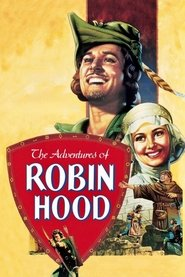

Seven Samurai


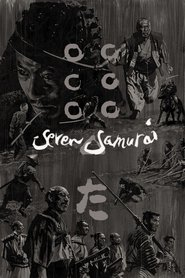

The Magnificent Seven


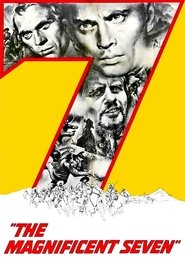

The Guns of Navarone


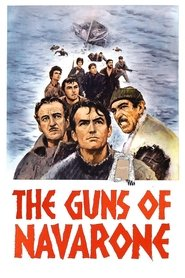

Yojimbo


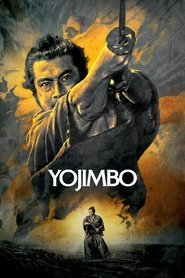

Dr. No


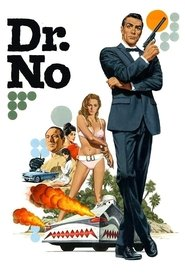

The Longest Day


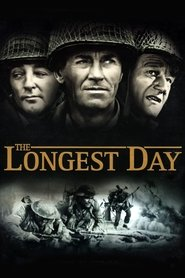

From Russia with Love


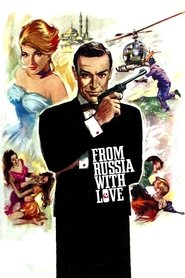

It's a Mad Mad Mad Mad World


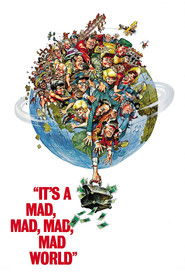

Goldfinger


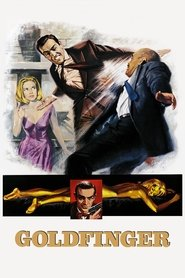

Thunderball


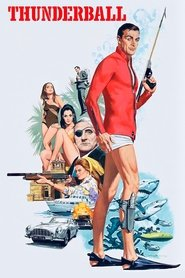

Bonnie and Clyde


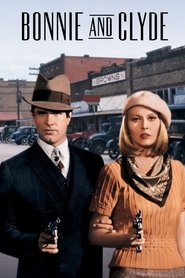

The Dirty Dozen


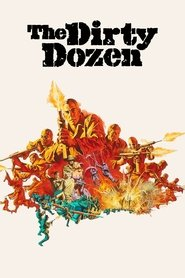

You Only Live Twice


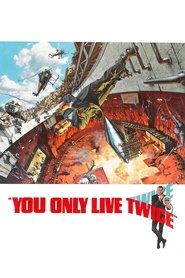

Bullitt


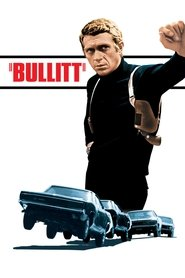

The Italian Job


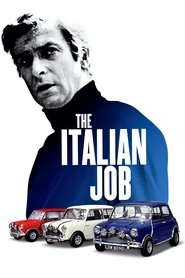

On Her Majesty's Secret Service


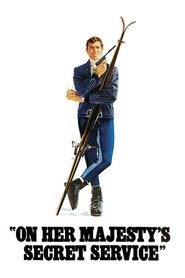

Where Eagles Dare


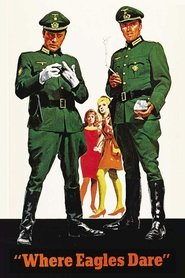

The Wild Bunch


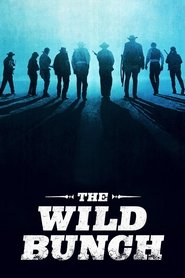

Beneath the Planet of the Apes


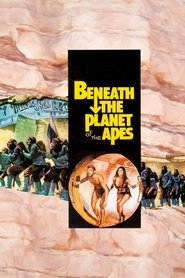

In [41]:
cursor = get_movies_by_genre("Action")

for m in cursor[0:20]:
    print(m["title"])
    display(Image(f"http://image.tmdb.org/t/p/w185{m['poster_path']}"))

## Conclusiones

Este proyecto muestra un flujo completo de procesamiento de datos:

- ingestión de datasets públicos
- enriquecimiento mediante APIs externas
- integración y limpieza de datos con Pandas
- almacenamiento en una base de datos NoSQL
- ejecución de consultas sobre el dataset resultante

Este tipo de pipeline es representativo de tareas comunes en proyectos de ingeniería de datos.